## Heart Failure Prediction Project

**Importing Libraries**

In [57]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_validate
from sklearn.model_selection import RepeatedStratifiedKFold
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
import optuna
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

**Section 1 - EDA**

In [58]:
df = pd.read_csv("/content/heart_failure_clinical_records_dataset.csv")
df.head()

,age,anaemia,creatinine_phosphokinase,diabetes,ejection_fraction,high_blood_pressure,platelets,serum_creatinine,serum_sodium,sex,smoking,time,DEATH_EVENT
0,75.0,0,582,0,20,1,265000.00,1.9,130,1,0,4,1
1,55.0,0,7861,0,38,0,263358.03,1.1,136,1,0,6,1
2,65.0,0,146,0,20,0,162000.00,1.3,129,1,1,7,1
3,50.0,1,111,0,20,0,210000.00,1.9,137,1,0,7,1
4,65.0,1,160,1,20,0,327000.00,2.7,116,0,0,8,1


In [59]:
df.isna().sum()

,0
age,0
anaemia,0
creatinine_phosphokinase,0
diabetes,0
ejection_fraction,0
high_blood_pressure,0
platelets,0
serum_creatinine,0
serum_sodium,0
sex,0


In [60]:
df.describe()

,age,anaemia,creatinine_phosphokinase,diabetes,ejection_fraction,high_blood_pressure,platelets,serum_creatinine,serum_sodium,sex,smoking,time,DEATH_EVENT
count,299.000000,299.000000,299.000000,299.000000,299.000000,299.000000,299.000000,299.00000,299.000000,299.000000,299.00000,299.000000,299.00000
mean,60.833893,0.431438,581.839465,0.418060,38.083612,0.351171,263358.029264,1.39388,136.625418,0.648829,0.32107,130.260870,0.32107
std,11.894809,0.496107,970.287881,0.494067,11.834841,0.478136,97804.236869,1.03451,4.412477,0.478136,0.46767,77.614208,0.46767
min,40.000000,0.000000,23.000000,0.000000,14.000000,0.000000,25100.000000,0.50000,113.000000,0.000000,0.00000,4.000000,0.00000
25%,51.000000,0.000000,116.500000,0.000000,30.000000,0.000000,212500.000000,0.90000,134.000000,0.000000,0.00000,73.000000,0.00000
50%,60.000000,0.000000,250.000000,0.000000,38.000000,0.000000,262000.000000,1.10000,137.000000,1.000000,0.00000,115.000000,0.00000
75%,70.000000,1.000000,582.000000,1.000000,45.000000,1.000000,303500.000000,1.40000,140.000000,1.000000,1.00000,203.000000,1.00000
max,95.000000,1.000000,7861.000000,1.000000,80.000000,1.000000,850000.000000,9.40000,148.000000,1.000000,1.00000,285.000000,1.00000


In [61]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 299 entries, 0 to 298
Data columns (total 13 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   age                       299 non-null    float64
 1   anaemia                   299 non-null    int64  
 2   creatinine_phosphokinase  299 non-null    int64  
 3   diabetes                  299 non-null    int64  
 4   ejection_fraction         299 non-null    int64  
 5   high_blood_pressure       299 non-null    int64  
 6   platelets                 299 non-null    float64
 7   serum_creatinine          299 non-null    float64
 8   serum_sodium              299 non-null    int64  
 9   sex                       299 non-null    int64  
 10  smoking                   299 non-null    int64  
 11  time                      299 non-null    int64  
 12  DEATH_EVENT               299 non-null    int64  
dtypes: float64(3), int64(10)
memory usage: 30.5 KB


In [62]:
df.duplicated().sum()

np.int64(0)

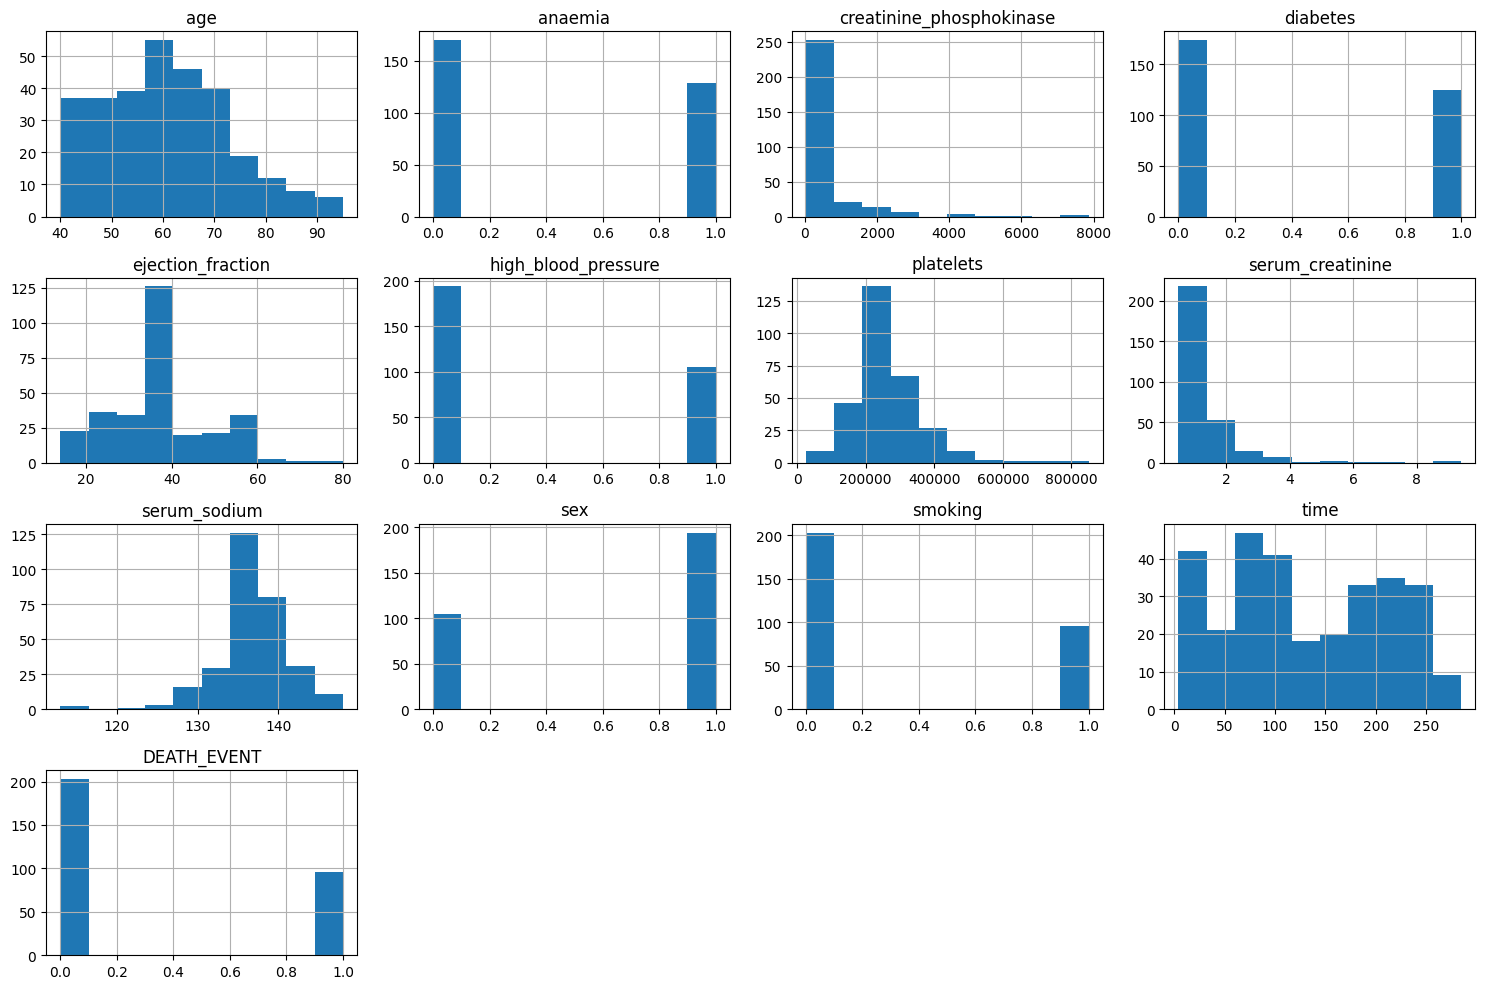

In [63]:
df.hist(figsize=(15, 10))
plt.tight_layout()
plt.show()

In [64]:
binary_features = [
    "anaemia",
    "diabetes",
    "high_blood_pressure",
    "sex",
    "smoking",
    "DEATH_EVENT"
]

for col in binary_features:
    counts = df[col].value_counts()
    percentages = df[col].value_counts(normalize=True) * 100

    summary = pd.DataFrame({
        "Count": counts,
        "Percentage": percentages
    })

    print(f"\n{col}")
    print(summary)


anaemia
         Count  Percentage
anaemia                   
0          170   56.856187
1          129   43.143813

diabetes
          Count  Percentage
diabetes                   
0           174    58.19398
1           125    41.80602

high_blood_pressure
                     Count  Percentage
high_blood_pressure                   
0                      194   64.882943
1                      105   35.117057

sex
     Count  Percentage
sex                   
1      194   64.882943
0      105   35.117057

smoking
         Count  Percentage
smoking                   
0          203   67.892977
1           96   32.107023

DEATH_EVENT
             Count  Percentage
DEATH_EVENT                   
0              203   67.892977
1               96   32.107023


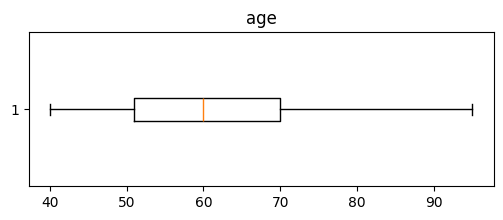

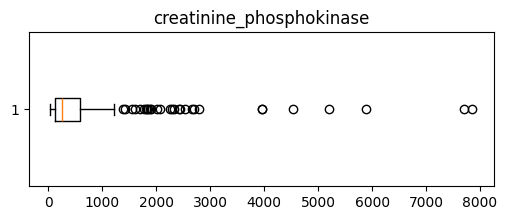

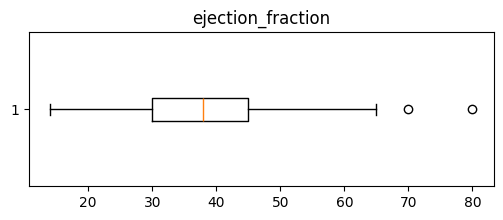

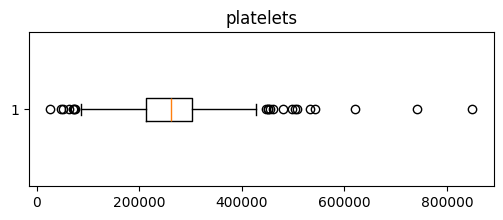

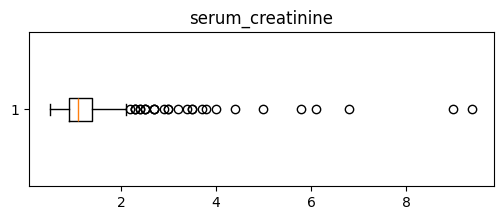

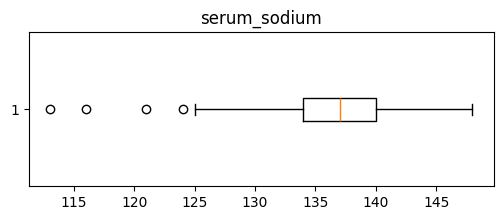

In [65]:
continuous_features = [
    "age",
    "creatinine_phosphokinase",
    "ejection_fraction",
    "platelets",
    "serum_creatinine",
    "serum_sodium"
]

for col in continuous_features:
    plt.figure(figsize=(6, 2))
    plt.boxplot(df[col], vert=False)
    plt.title(col)
    plt.show()

Outlier observations:

Some features, especially serum creatinine, CPK, and platelets, contain extreme values. These values were kept because they are possible in heart failure patients and may be useful for predicting mortality.

In [66]:
df.groupby("DEATH_EVENT").mean()

,age,anaemia,creatinine_phosphokinase,diabetes,ejection_fraction,high_blood_pressure,platelets,serum_creatinine,serum_sodium,sex,smoking,time
DEATH_EVENT,,,,,,,,,,,,
0,58.761906,0.408867,540.054187,0.418719,40.26601,0.325123,266657.489901,1.184877,137.216749,0.650246,0.325123,158.339901
1,65.215281,0.479167,670.197917,0.416667,33.46875,0.406250,256381.044792,1.835833,135.375000,0.645833,0.312500,70.885417


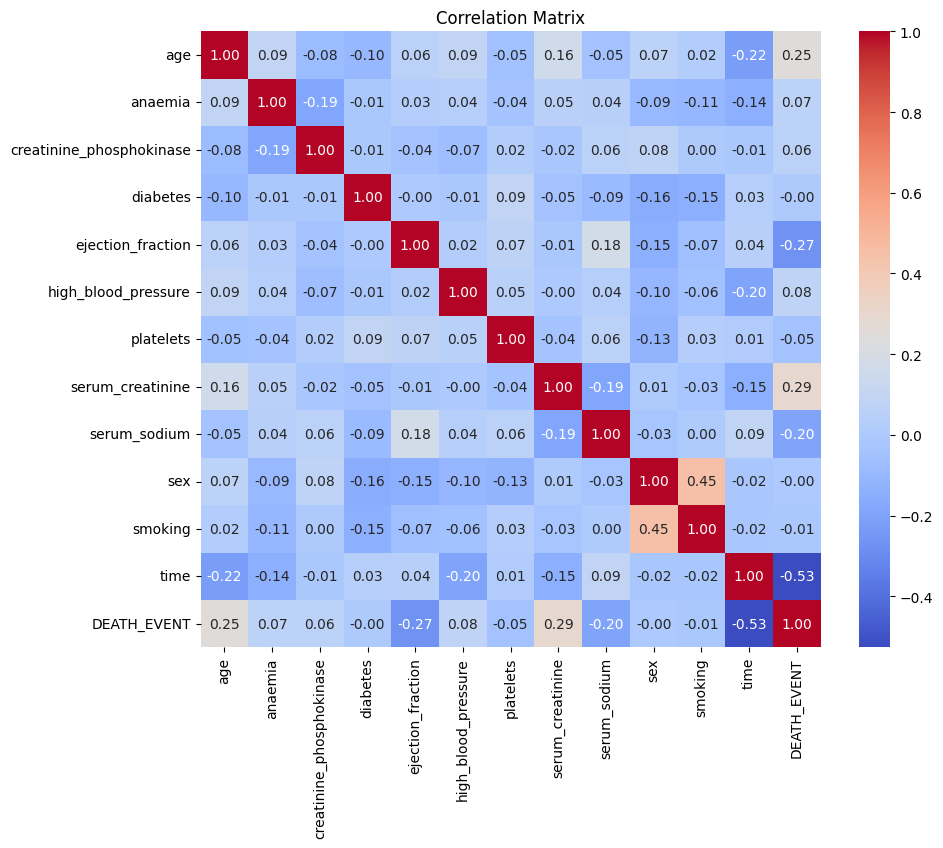

In [67]:
corr_matrix = df.corr()
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Matrix")
plt.show()

Correlation observations:

 DEATH_EVENT shows its strongest association with follow-up time (-0.53), followed by serum creatinine (+0.29), ejection fraction (-0.27), age (+0.25), and serum sodium (-0.20). The strong association with time requires special consideration because follow-up duration may not be available at the intended prediction point and could introduce leakage.

 For this reason, the time feature will be excluded before the training phase.

**Section 2 - Data Preprocessing**

In [68]:
X = df.drop(columns=["DEATH_EVENT", "time"])
y = df["DEATH_EVENT"]

In [69]:
for col in ["creatinine_phosphokinase", "serum_creatinine"]:
    X[col] = np.log1p(X[col])
#creatinine phosphokinase and serum creatinine showed strongly right-skewed distributions.
#A log1p transformation was applied to reduce the influence of extreme values while retaining all observations.

In [70]:
X.shape, y.shape

((299, 11), (299,))

In [71]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

**Section 3 - Modeling**

In [72]:
cv = RepeatedStratifiedKFold(n_splits=5, n_repeats=5, random_state=42)

In [73]:
logistic_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression())
])

knn_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("model", KNeighborsClassifier())
])

tree_pipeline = Pipeline([
    ("model", DecisionTreeClassifier(random_state=42))
])

forest_pipeline = Pipeline([
    ("model", RandomForestClassifier(random_state=42))
])

svm_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("model", SVC(probability=True))
])

In [74]:
scoring = {
    "accuracy": "accuracy",
    "precision": "precision",
    "recall": "recall",
    "f1": "f1",
    "roc_auc": "roc_auc"
}

In [75]:
logistic_cv = cross_validate(
    logistic_pipeline,
    X_train,
    y_train,
    cv=cv,
    scoring=scoring
)

knn_cv = cross_validate(
    knn_pipeline,
    X_train,
    y_train,
    cv=cv,
    scoring=scoring
)

tree_cv = cross_validate(
    tree_pipeline,
    X_train,
    y_train,
    cv=cv,
    scoring=scoring
)

forest_cv = cross_validate(
    forest_pipeline,
    X_train,
    y_train,
    cv=cv,
    scoring=scoring
)

svm_cv = cross_validate(
    svm_pipeline,
    X_train,
    y_train,
    cv=cv,
    scoring=scoring
)

In [76]:
results = pd.DataFrame({
    "Logistic Regression": {
        "Accuracy": logistic_cv["test_accuracy"].mean(),
        "Precision": logistic_cv["test_precision"].mean(),
        "Recall": logistic_cv["test_recall"].mean(),
        "F1": logistic_cv["test_f1"].mean(),
        "ROC-AUC": logistic_cv["test_roc_auc"].mean()
    },
    "KNN": {
        "Accuracy": knn_cv["test_accuracy"].mean(),
        "Precision": knn_cv["test_precision"].mean(),
        "Recall": knn_cv["test_recall"].mean(),
        "F1": knn_cv["test_f1"].mean(),
        "ROC-AUC": knn_cv["test_roc_auc"].mean()
    },
    "Decision Tree": {
        "Accuracy": tree_cv["test_accuracy"].mean(),
        "Precision": tree_cv["test_precision"].mean(),
        "Recall": tree_cv["test_recall"].mean(),
        "F1": tree_cv["test_f1"].mean(),
        "ROC-AUC": tree_cv["test_roc_auc"].mean()
    },
    "Random Forest": {
        "Accuracy": forest_cv["test_accuracy"].mean(),
        "Precision": forest_cv["test_precision"].mean(),
        "Recall": forest_cv["test_recall"].mean(),
        "F1": forest_cv["test_f1"].mean(),
        "ROC-AUC": forest_cv["test_roc_auc"].mean()
    },
    "SVM": {
        "Accuracy": svm_cv["test_accuracy"].mean(),
        "Precision": svm_cv["test_precision"].mean(),
        "Recall": svm_cv["test_recall"].mean(),
        "F1": svm_cv["test_f1"].mean(),
        "ROC-AUC": svm_cv["test_roc_auc"].mean()
    }
}).T

(results * 100).round(2)

,Accuracy,Precision,Recall,F1,ROC-AUC
Logistic Regression,73.98,64.69,44.23,51.56,78.46
KNN,69.13,54.70,25.03,33.67,64.51
Decision Tree,66.87,49.57,48.82,48.52,62.11
Random Forest,75.65,68.80,49.45,55.83,78.00
SVM,73.73,67.14,40.57,49.49,76.82


Baseline Model Comparison:

Random Forest produced the strongest baseline results on most metrics, achieving 75.65% accuracy, 68.80% precision, 49.45% recall, and a 55.83% F1-score. Logistic Regression achieved the highest ROC-AUC (78.46%), just ahead of Random Forest (78.00%), so the two perform almost equally in discrimination. SVM followed with a ROC-AUC of 76.82%. KNN and Decision Tree showed clearly weaker performance (ROC-AUC of 64.51% and 62.11%). Recall was low across all models (25-49%), meaning many deaths are missed, so this will be a focus during tuning. Based on these results, Random Forest, Logistic Regression, and SVM were selected for hyperparameter tuning.

**Section 4 - Hyperparameter Tuning**

In [77]:
optuna.logging.set_verbosity(optuna.logging.WARNING)

def objective(trial):
    C = trial.suggest_float("C", 0.001, 100, log=True)
    class_weight = trial.suggest_categorical("class_weight", [None, "balanced"])

    pipe = Pipeline([
        ("scaler", StandardScaler()),
        ("model", LogisticRegression(C=C, class_weight=class_weight, max_iter=1000))
    ])

    scores = cross_val_score(pipe, X_train, y_train, cv=cv, scoring="f1")
    return scores.mean()

study = optuna.create_study(direction="maximize", sampler=optuna.samplers.TPESampler(seed=42))
study.optimize(objective, n_trials=30)

print(study.best_params)
print(study.best_value)

{'C': 0.044935212941595616, 'class_weight': 'balanced'}
0.6592652857704904


In [78]:
def rf_objective(trial):
    n_estimators = trial.suggest_int("n_estimators", 100, 300)
    max_depth = trial.suggest_int("max_depth", 2, 10)
    min_samples_leaf = trial.suggest_int("min_samples_leaf", 1, 10)
    max_features = trial.suggest_categorical("max_features", ["sqrt", "log2"])
    class_weight = trial.suggest_categorical("class_weight", [None, "balanced"])

    model = RandomForestClassifier(
        n_estimators=n_estimators,
        max_depth=max_depth,
        min_samples_leaf=min_samples_leaf,
        max_features=max_features,
        class_weight=class_weight,
        random_state=42,
        n_jobs=-1
    )

    scores = cross_val_score(model, X_train, y_train, cv=cv, scoring="f1")
    return scores.mean()

rf_study = optuna.create_study(direction="maximize", sampler=optuna.samplers.TPESampler(seed=42))
rf_study.optimize(rf_objective, n_trials=30)

print(rf_study.best_params)
print(rf_study.best_value)

{'n_estimators': 193, 'max_depth': 9, 'min_samples_leaf': 9, 'max_features': 'log2', 'class_weight': 'balanced'}
0.6523765951404539


In [79]:
def svm_objective(trial):
    C = trial.suggest_float("C", 0.01, 100, log=True)
    kernel = trial.suggest_categorical("kernel", ["rbf", "linear"])
    gamma = trial.suggest_float("gamma", 0.0001, 1, log=True)
    class_weight = trial.suggest_categorical("class_weight", [None, "balanced"])

    pipe = Pipeline([
        ("scaler", StandardScaler()),
        ("model", SVC(C=C, kernel=kernel, gamma=gamma, class_weight=class_weight))
    ])

    scores = cross_val_score(pipe, X_train, y_train, cv=cv, scoring="f1")
    return scores.mean()

svm_study = optuna.create_study(direction="maximize", sampler=optuna.samplers.TPESampler(seed=42))
svm_study.optimize(svm_objective, n_trials=30)

print(svm_study.best_params)
print(svm_study.best_value)

{'C': 0.10757412206633195, 'kernel': 'linear', 'gamma': 0.005570049141515658, 'class_weight': 'balanced'}
0.65696025666


Optimization Metric:

F1-score was used because the dataset is imbalanced and we care about correctly identifying patients who died. It balances recall (catching more deaths) with precision (avoiding too many false alarms), making it more useful than accuracy alone for this problem

**Section 5 - Tuned Model Comparison**

In [80]:
tuned_models = {
    "Logistic Regression": Pipeline([
        ("scaler", StandardScaler()),
        ("model", LogisticRegression(
            **study.best_params,
            max_iter=1000
        ))
    ]),

    "Random Forest": RandomForestClassifier(
        **rf_study.best_params,
        random_state=42,
        n_jobs=-1
    ),

    "SVM": Pipeline([
        ("scaler", StandardScaler()),
        ("model", SVC(
            **svm_study.best_params,
            probability=True
        ))
    ])
}

In [81]:
tuned_results = {}

for name, model in tuned_models.items():

    scores = cross_validate(
        model,
        X_train,
        y_train,
        cv=cv,
        scoring=scoring
    )

    tuned_results[name] = {
        "Accuracy": scores["test_accuracy"].mean(),
        "Precision": scores["test_precision"].mean(),
        "Recall": scores["test_recall"].mean(),
        "F1": scores["test_f1"].mean(),
        "ROC-AUC": scores["test_roc_auc"].mean()
    }

tuned_results_df = pd.DataFrame(tuned_results).T * 100
tuned_results_df.round(2)

,Accuracy,Precision,Recall,F1,ROC-AUC
Logistic Regression,76.09,61.71,72.03,65.93,78.80
Random Forest,76.91,64.67,67.07,65.24,78.07
SVM,75.42,60.37,73.32,65.70,78.44


Comparison:





After hyperparameter optimization, all three models performed very similarly in cross-validation. Logistic Regression achieved the highest mean F1-score (65.93%) and ROC-AUC (78.80%), while the differences between the models were small. Since F1-score was the primary model-selection metric, Logistic Regression was selected as the final model. Its simplicity and interpretability also supported the decision.

**Section 6 - Threshold Optimization**

In [82]:
final_model = tuned_models["Logistic Regression"]

In [83]:
threshold_cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

oof_proba = cross_val_predict(
    final_model,
    X_train,
    y_train,
    cv=threshold_cv,
    method="predict_proba",
    n_jobs=-1
)[:, 1]

In [84]:
thresholds = np.arange(0.10, 0.91, 0.01)

In [85]:
threshold_rows = []

for threshold in thresholds:
    y_pred = (oof_proba >= threshold).astype(int)

    precision = precision_score(y_train, y_pred)
    recall = recall_score(y_train, y_pred)
    f1 = f1_score(y_train, y_pred)

    threshold_rows.append([
        threshold,
        precision,
        recall,
        f1
    ])

In [86]:
threshold_results = pd.DataFrame(
    threshold_rows,
    columns=["Threshold", "Precision", "Recall", "F1"]
)

best_row = threshold_results.loc[
    threshold_results["F1"].idxmax()
]

best_row

,38
Threshold,0.480000
Precision,0.608247
Recall,0.766234
F1,0.678161


In [87]:
best_threshold = best_row["Threshold"]

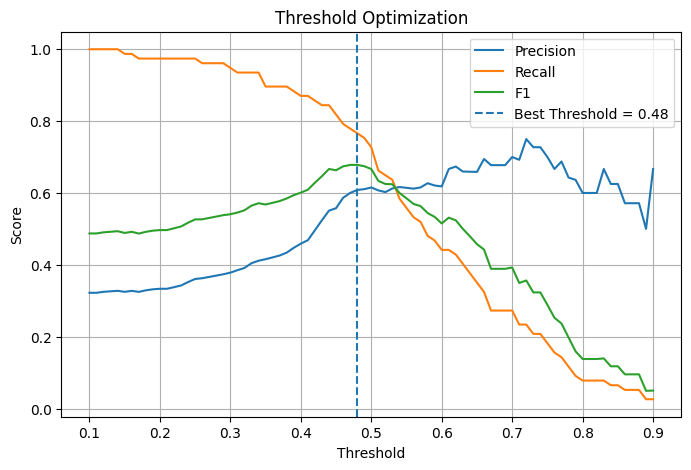

In [88]:
plt.figure(figsize=(8, 5))

plt.plot(
    threshold_results["Threshold"],
    threshold_results["Precision"],
    label="Precision"
)

plt.plot(
    threshold_results["Threshold"],
    threshold_results["Recall"],
    label="Recall"
)

plt.plot(
    threshold_results["Threshold"],
    threshold_results["F1"],
    label="F1"
)

plt.axvline(
    best_threshold,
    linestyle="--",
    label=f"Best Threshold = {best_threshold:.2f}"
)

plt.xlabel("Threshold")
plt.ylabel("Score")
plt.title("Threshold Optimization")
plt.legend()
plt.grid()

plt.show()

Threshold Optimization:

Different classification thresholds were evaluated using out-of-fold predictions from the training data. The threshold that produced the highest F1-score was 0.48, with an F1-score of approximately 0.678. This threshold was selected for the final model evaluation.

**Section 7 - Final Model Evaluation**

In [89]:
final_model.fit(X_train, y_train)

Pipeline(steps=[('scaler', StandardScaler()),
                ('model',
                 LogisticRegression(C=0.044935212941595616,
                                    class_weight='balanced', max_iter=1000))])

In [90]:
y_test_proba = final_model.predict_proba(X_test)[:, 1]
y_test_pred = (y_test_proba >= best_threshold).astype(int)

In [91]:
final_accuracy = accuracy_score(y_test, y_test_pred)
final_precision = precision_score(y_test, y_test_pred)
final_recall = recall_score(y_test, y_test_pred)
final_f1 = f1_score(y_test, y_test_pred)
final_roc_auc = roc_auc_score(y_test, y_test_proba)

print(f"Accuracy:  {final_accuracy:.4f}")
print(f"Precision: {final_precision:.4f}")
print(f"Recall:    {final_recall:.4f}")
print(f"F1-score:  {final_f1:.4f}")
print(f"ROC-AUC:   {final_roc_auc:.4f}")

Accuracy:  0.6667
Precision: 0.4762
Recall:    0.5263
F1-score:  0.5000
ROC-AUC:   0.7535


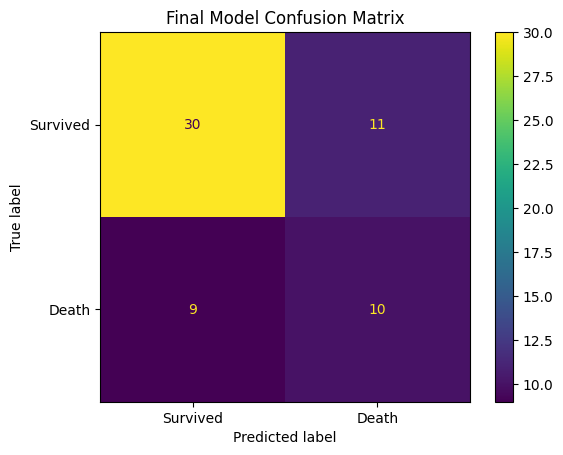

In [92]:
cm = confusion_matrix(y_test, y_test_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Survived", "Death"]
)

disp.plot()
plt.title("Final Model Confusion Matrix")
plt.show()

**Section 8 - Conclusion And Limitations**



This project developed a machine learning model to predict mortality among heart failure patients using baseline clinical features.

Several classification models were evaluated using stratified cross-validation, and the strongest candidates were further optimized using Optuna. Logistic Regression was selected as the final model based on its cross-validation performance, and the classification threshold was optimized using out-of-fold predictions from the training data.

On the held-out test set, the final model achieved:

- Accuracy: 66.67%
- Precision: 47.62%
- Recall: 52.63%
- F1-score: 50.00%
- ROC-AUC: 75.35%

The results show that the model has some ability to distinguish higher-risk from lower-risk patients, as indicated by the ROC-AUC, but its final classification performance remains limited. In particular, the model missed a considerable number of actual death cases and also produced false-positive predictions.

### Limitations

- The dataset contains only 299 patients, which makes model evaluation less stable and limits generalization.
- Mortality was treated as a binary classification problem, even though patients had different follow-up durations. A survival analysis approach would be more appropriate for directly modeling time-to-event outcomes.
- The final test set was relatively small, so a small number of prediction errors can significantly affect the reported metrics.
- The model was developed for educational purposes and has not been clinically validated.
- The dataset comes from a limited population, so the results should not be assumed to generalize to broader or different patient populations.

Despite these limitations, the project demonstrates a complete machine learning workflow, including exploratory data analysis, leakage prevention, preprocessing, cross-validation, hyperparameter optimization, model selection, threshold optimization, and final evaluation on held-out data.